In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:

import argparse
import time
import numpy as np
from sklearn.datasets import make_blobs

import hdbscan


from core_sg import CoreSGClusterer

In [3]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def scatter_labels(ax, X_plot, labels, title):
    unique_labels = np.unique(labels)

    non_noise_labels = [lab for lab in unique_labels if lab != -1]
    cmap = plt.cm.get_cmap("tab20", max(1, len(non_noise_labels)))
    color_map = {lab: cmap(i) for i, lab in enumerate(non_noise_labels)}

    for lab in unique_labels:
        mask = labels == lab

        if lab == -1:
            ax.scatter(
                X_plot[mask, 0],
                X_plot[mask, 1],
                label="noise (-1)",
                alpha=0.8,
                marker="x",
                s=40,
                c="black",
            )
        else:
            ax.scatter(
                X_plot[mask, 0],
                X_plot[mask, 1],
                label=f"cluster {lab}",
                alpha=0.8,
                s=30,
                c=[color_map[lab]],
            )

    ax.set_title(title)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.legend(loc="best", fontsize=8)

In [5]:
n = 5000
d = 2
centers = 10
k = 30
seed = 42
atol = 1e-12
rtol = 1e-9

print(f"Generating synthetic dataset: n={n}, d={d}, centers={centers}, seed={seed}")
X, _ = make_blobs(
    n_samples=n,
    n_features=d,
    centers=centers,
    random_state=seed)

Generating synthetic dataset: n=5000, d=2, centers=10, seed=42


# Building Core-SG

In [6]:
%%time
# --- Build Core-SG (calculando pairwise dentro) ---
core_sg_clusterer = CoreSGClusterer(k_max=k, metric='euclidean',p=2,verbose=1,no_noise=False, match_reference_implementation=True)
core_sg_clusterer.fit(X, k=k)
core_sg_ = core_sg_clusterer.core_sg_

Core-SG build done in 4.25s
CPU times: user 4.51 s, sys: 369 ms, total: 4.88 s
Wall time: 4.25 s


/tmp/ipykernel_14506/3925052488.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", max(1, len(non_noise_labels)))


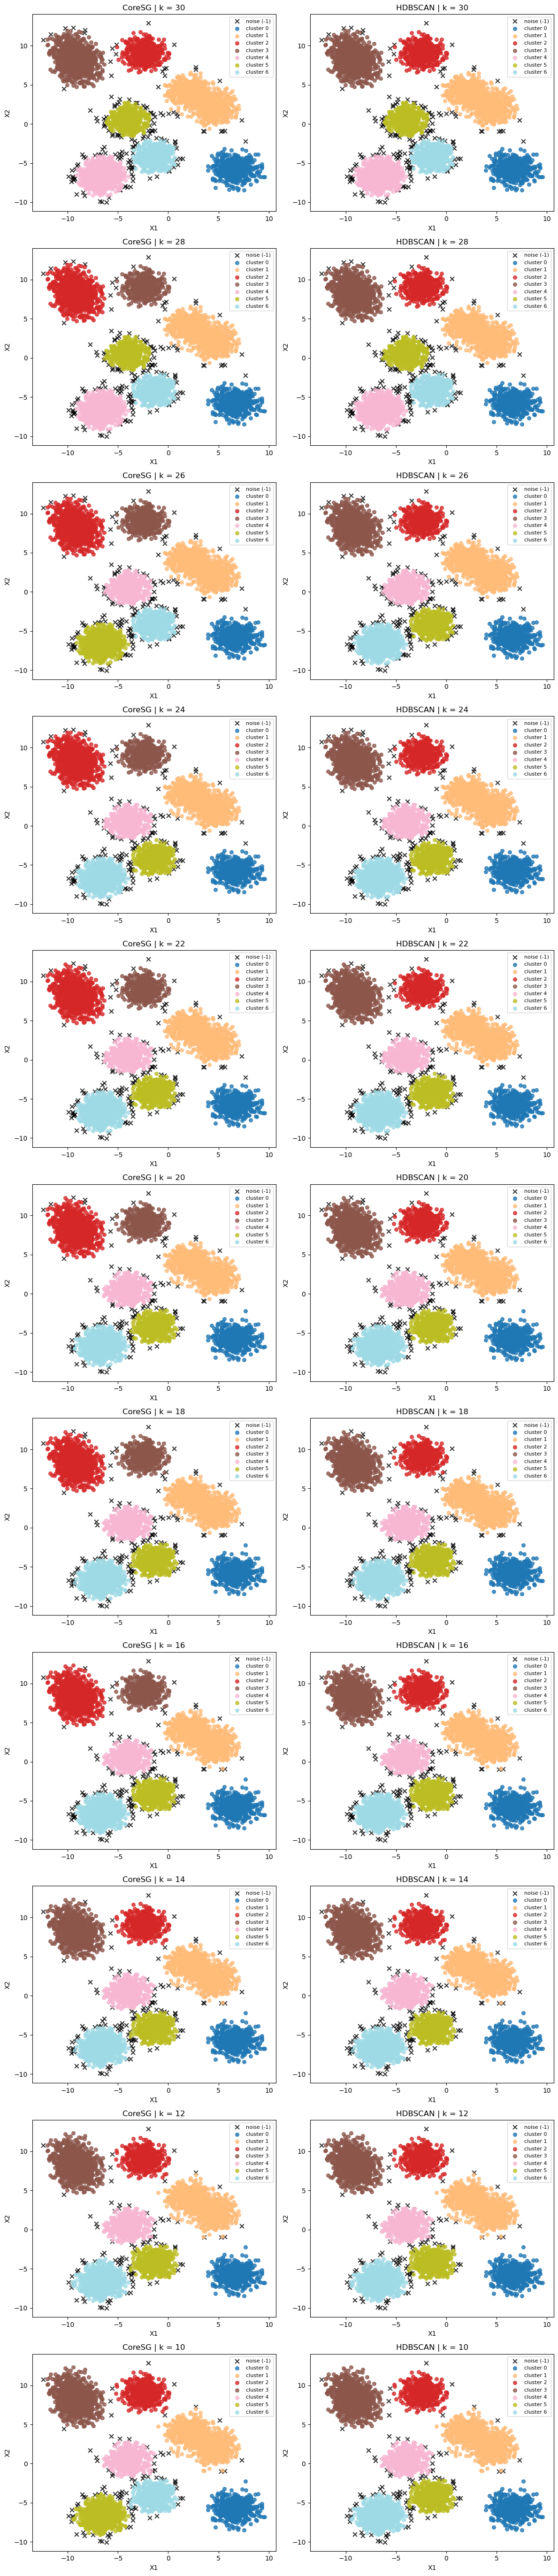

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np

from hdbscan import HDBSCAN




results = []
d = {}
d[k] = {"core_sg":4.7,"hdbscan":0}

core_sg_.set_verbose(False)

for k_iter in range(k, 8, -2):

    if k_iter not in d:
        d[k_iter] = {"core_sg":0,"hdbscan":0}
    # CoreSG
    t0 = time.time()
    core_sg_.extract_hierarchy_from_core_sg(k_iter)
    d[k_iter]['core_sg'] += (time.time() - t0)
    labels_core_sg = core_sg_.labels_.copy()

    # HDBSCAN
    t0 = time.time()
    hdb = hdbscan.HDBSCAN(
                min_cluster_size=k_iter,
                min_samples=k_iter,
                metric="euclidean",
                algorithm="generic",
                approx_min_span_tree=False,
                gen_min_span_tree=True,
                match_reference_implementation=True,
            ).fit(X)
    d[k_iter]['hdbscan'] += (time.time() - t0)
    labels_hdbscan = hdb.labels_

    results.append((k_iter, labels_core_sg, labels_hdbscan))

n_plots = len(results)
n_rows = n_plots
n_cols = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))

axes = np.atleast_2d(axes)

for row_idx, (k_iter, labels_core_sg, labels_hdbscan) in enumerate(results):
    ax_left = axes[row_idx, 0]
    ax_right = axes[row_idx, 1]

    scatter_labels(
        ax_left,
        X,
        labels_core_sg,
        title=f"CoreSG | k = {k_iter}",
    )

    scatter_labels(
        ax_right,
        X,
        labels_hdbscan,
        title=f"HDBSCAN | k = {k_iter}",
    )

plt.tight_layout()
plt.show()

# Time Comparision

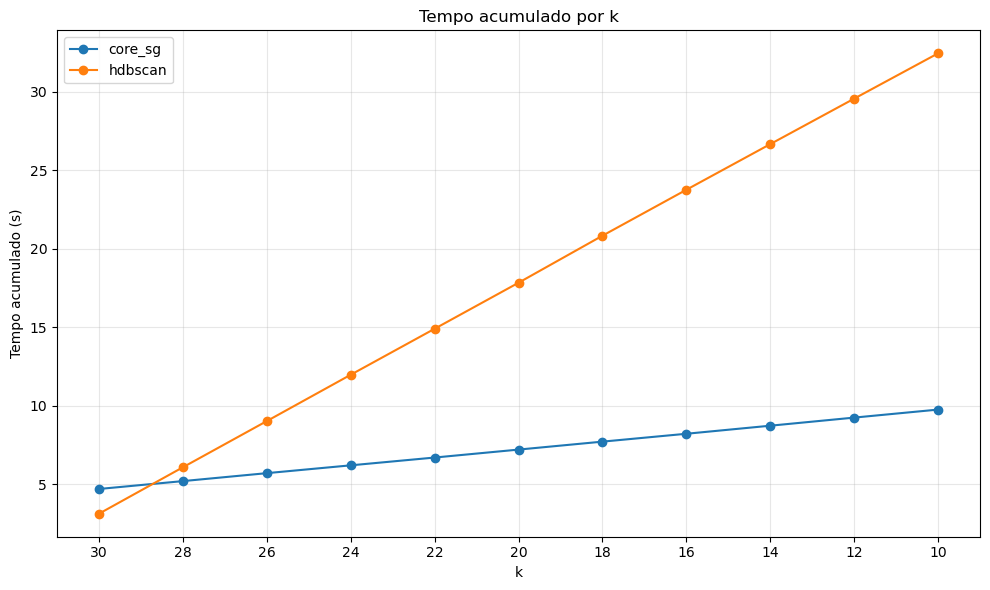

In [13]:
import matplotlib.pyplot as plt

times = {
    30: {'core_sg': 4.700009059906006, 'hdbscan': 3.1256155967712402},
    28: {'core_sg': 0.5013628005981445, 'hdbscan': 2.9569053649902344},
    26: {'core_sg': 0.5063560009002686, 'hdbscan': 2.9408884048461914},
    24: {'core_sg': 0.49776411056518555, 'hdbscan': 2.950127363204956},
    22: {'core_sg': 0.49672603607177734, 'hdbscan': 2.928081750869751},
    20: {'core_sg': 0.505972146987915, 'hdbscan': 2.9312169551849365},
    18: {'core_sg': 0.5063366889953613, 'hdbscan': 2.994563102722168},
    16: {'core_sg': 0.5015699863433838, 'hdbscan': 2.9257588386535645},
    14: {'core_sg': 0.513390302658081, 'hdbscan': 2.9067461490631104},
    12: {'core_sg': 0.5159304141998291, 'hdbscan': 2.8958253860473633},
    10: {'core_sg': 0.5105502605438232, 'hdbscan': 2.8851819038391113},
}

# ordem desejada no eixo X: 30, 28, ..., 10
ks = sorted(times.keys(), reverse=True)
x_labels = [str(k) for k in ks]

core_sg_cum = []
hdbscan_cum = []

acc_core_sg = 0.0
acc_hdbscan = 0.0

for k in ks:
    acc_core_sg += times[k]['core_sg']
    acc_hdbscan += times[k]['hdbscan']
    core_sg_cum.append(acc_core_sg)
    hdbscan_cum.append(acc_hdbscan)

plt.figure(figsize=(10, 6))
plt.plot(x_labels, core_sg_cum, marker='o', label='core_sg')
plt.plot(x_labels, hdbscan_cum, marker='o', label='hdbscan')

plt.xlabel('k')
plt.ylabel('Tempo acumulado (s)')
plt.title('Tempo acumulado por k')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()